<img src='./img/thrivegeo_logo_with_font.png' width="15%" style="float: right">
<br>


<center><h1> 🌊 Monitoring Marine Heat Waves impacting Spain 🌡️ </h1></center>


<a id="example1"></a>

## Introduction

The Mediterranean Sea is warming at twice the rate of the global ocean, earning its status as a marine heatwave hotspot.<br>
The Balearic Sea, a sub-basin of the Western Mediterranean Sea, represents a vital ecological and economic hub: its waters nurture extensive *Posidonia oceanica* meadows (critical carbon sinks), host key spawning grounds for the Atlantic Bluefin Tuna (*Thunnus thynnus*), and support vibrant artisanal fisheries. It is also a key habitat of the critically endangered Mediterranean fan mussel (*Pinnus nobilis*). 

In recent years, severe summer marine heatwaves (MHWs) have triggered widespread mass mortality of benthic invertebrates, altered pelagic food webs, and disrupted local fishery yields. While global visualisation platforms like Copernicus's [**My Ocean Health** portal](https://myoceanhealth.marine.copernicus.eu/en) provide an excellent high-level overview, their coarse rendering and zoom limits make detailed regional assessments difficult.

In this tutorial, we will explore how to go beyond standard web viewers and make use of the [Copernicus Marine Toolbox](https://help.marine.copernicus.eu/en/articles/7949409-copernicus-marine-toolbox-introduction).

### By the end of this tutorial, you will be able to...
* 🔌 access data throguh the `copernicusmarine` **Python API** and `xarray`
* 🐍 programmatically extract high-resolution Sea Surface Temperature (SST) data over an area of interest.
* 🗺️ render custom spatial maps of daily and monthly MHW categories.

### Notebook Outline
* [Introduction](#example1)
* [1️⃣ : Catalogue Exploration](#example2)
* [2️⃣ : Marine Heat Waves Monitoring](#example3)
* [3️⃣ : Now it is your Turn](#example4)
* [4️⃣ : Conclusion](#example5)

<hr>

### Python modules

| Module name | Description |
| :---: | :---|
| **copernicusmarine** |The [Copernicusmarine Toolbox](https://help.marine.copernicus.eu/en/articles/7949409-copernicus-marine-toolbox-introduction) interoperates with the Copernicus Marine Data Store to explore metadata and retrieve data for any type of product: numerical models, satellite and/or in situ observations. |
| **xarray** | [Xarray](http://xarray.pydata.org/en/stable/) is a very user friendly library to manipulate NetCDF files within Python. It introduces labels in the form of dimensions, coordinates and attributes on top of raw NumPy-like arrays, which allows for a more intuitive, more concise, and less error-prone developer experience. |
| **cartopy** |[Cartopy](https://scitools.org.uk/cartopy/docs/latest/) is a library for plotting maps and geospatial data analyses in Python. |



In [1]:
import copernicusmarine
import xarray as xr
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

### Functions

In [2]:
def available_products(catalogue_search):

    products_summary = []
    for product in catalogue_search.products:
        products_summary.append({
            "Product Title": product.title,
            "Product ID": product.product_id,
            "Sources": ", ".join(product.sources) if product.sources else "N/A",
            "Number of Datasets": len(product.datasets),
            # "Datasets": product.datasets
        })

    df_products = pd.DataFrame(products_summary)
    return df_products

In [3]:
def available_datasets(product_ret):
    prod_ids = []
    variables_per_prod=[]
    for prod in range(len(product_ret.products)):
        for data_s in range(len(product_ret.products[prod].datasets)):
            prod_ids.append(product_ret.products[prod].datasets[data_s].dataset_id)
            int_var = []
            for variable in range(len(product_ret.products[prod].datasets[data_s].versions[0].parts[0].services[0].variables)):
                int_var.append(product_ret.products[prod].datasets[data_s].versions[0].parts[0].services[0].variables[variable].standard_name)
            variables_per_prod.append(int_var)

    return [prod_ids,variables_per_prod]

### Credentials Definition

To access the Copernicus Marine Catalogue, you need to create an account and create a **configuration file**.

You can follow [this tutorial](https://help.marine.copernicus.eu/en/articles/8185007-copernicus-marine-toolbox-credentials-configuration). This configuration only needs to be done once. 


<a id="example2"></a>

## 1️⃣ : Catalogue Exploration

The Copernicus Marine Data Store hosts 307 Products available to the public through their [online portal](https://data.marine.copernicus.eu/products?disc=facets). As explored beforehand, we can discover the data through their web interface. While we can browse datasets visually via the web interface, we can also programmatically discover and filter them using Python's`copernicusmarine`.<br>

Once we have imported our required modules and initialised our credentials, we access the catalogue using the `describe()` function. This returns a **Pydantic `BaseModel`** containing full metadata fields.

In [4]:
# 1. Load the entire catalog
catalogue = copernicusmarine.describe()


Fetching catalogue 1: 100%|██████████| 2/2 [00:16<00:00,  8.25s/it]


When we inspect the first element, we see a structured response detailing available assets:

In [5]:
catalogue.products[0]

CopernicusMarineProduct(title='Antarctic Sea Ice Extent from Reanalysis', product_id='ANTARCTIC_OMI_SI_extent', thumbnail_url='https://documentation.marine.copernicus.eu/IMG/ANTARCTIC_OMI_SI_extent.png', description='**DEFINITION**\n\nEstimates of Antarctic sea ice extent are obtained from the surface of oceans grid cells that have at least 15% sea ice concentration. These values are cumulated in the entire Southern Hemisphere (excluding ice lakes) and from 1993 up to real time aiming to:\ni) obtain the Antarctic sea ice extent as expressed in millions of km squared (106 km2) to monitor both the large-scale variability and mean state and change.\nii) to monitor the change in sea ice extent as expressed in millions of km squared per decade (106 km2/decade), or in sea ice extent loss/gain since the beginning of the time series as expressed in percent per decade (%/decade; reference period being the first date of the key figure b) dot-dashed trend line, Vaughan et al., 2013)). For the Sou

To inspect this metadata easily, we convert the `BaseModel` in a data frame, to have a glimpse of what each of the product contains like:

- Product Title
- Product ID
- Sources
- Number of Datasets

In [6]:
#  Extract top-level Product information
products_summary = []
for product in catalogue.products:
    products_summary.append({
        "Product Title": product.title,
        "Product ID": product.product_id,
        "Sources": ", ".join(product.sources) if product.sources else "N/A",
        "Number of Datasets": len(product.datasets)
    })

df_products = pd.DataFrame(products_summary)

# Display the total count and top 10 products
print(f"Total Products Available: {len(df_products)}")
df_products

Total Products Available: 307


,Product Title,Product ID,Sources,Number of Datasets
0,Antarctic Sea Ice Extent from Reanalysis,ANTARCTIC_OMI_SI_extent,Numerical models,1
1,Antarctic Monthly Sea Ice Extent from Observat...,ANTARCTIC_OMI_SI_extent_obs,Satellite observations,1
2,Arctic Ocean Biogeochemistry Analysis and Fore...,ARCTIC_ANALYSISFORECAST_BGC_002_004,Numerical models,2
3,Arctic Ocean Physics Analysis and Forecast,ARCTIC_ANALYSISFORECAST_PHY_002_001,Numerical models,4
4,Arctic Ocean Sea Ice Analysis and Forecast,ARCTIC_ANALYSISFORECAST_PHY_ICE_002_011,Numerical models,2
...,...,...,...,...
302,Global Ocean Daily Gridded Sea Surface Winds f...,WIND_GLO_PHY_L3_NRT_012_002,Satellite observations,36
303,Global Ocean Hourly Reprocessed Sea Surface Wi...,WIND_GLO_PHY_L4_MY_012_006,"Numerical models, Satellite observations",2
304,Global Ocean Hourly Sea Surface Wind and Stres...,WIND_GLO_PHY_L4_NRT_012_004,"Numerical models, Satellite observations",1
305,High-resolution L3 Sea Surface Wind from MY Sa...,WIND_MED_PHY_HR_L3_MY_012_109,Satellite observations,4


The Catalog, also allow us to search based on keywords. We are interested to explore datasets targeting the **Mediterranean Sea**.

In [7]:
heat_cat = copernicusmarine.describe(contains=["Mediterranean Sea"])

Fetching catalogue 1: 100%|██████████| 2/2 [00:16<00:00,  8.34s/it]


Since we are targeting the Mediterranean Sea, we build a custom helper function `available_products` to filter top-level product metadata automatically. Through this function, we identify 43 out of 307 products specific to the **Mediterranean Sea**.

In [8]:
datasets_s = available_products(heat_cat)
datasets_s

,Product Title,Product ID,Sources,Number of Datasets
0,Black Sea Physics Analysis and Forecast,BLKSEA_ANALYSISFORECAST_PHY_007_001,Numerical models,30
1,Mediterrranean Outflow Water Index from Reanal...,IBI_OMI_WMHE_mow,"In-situ observations, Numerical models",4
2,Mediterranean Sea- In-Situ Near Real Time Obse...,INSITU_MED_PHYBGCWAV_DISCRETE_MYNRT_013_035,In-situ observations,1
3,Mediterranean Sea Biogeochemistry Analysis and...,MEDSEA_ANALYSISFORECAST_BGC_006_014,Numerical models,13
4,Mediterranean Sea Physics Analysis and Forecast,MEDSEA_ANALYSISFORECAST_PHY_006_013,Numerical models,25
5,Mediterranean Sea Waves Analysis and Forecast,MEDSEA_ANALYSISFORECAST_WAV_006_017,Numerical models,2
6,Mediterranean Sea Biogeochemistry Reanalysis,MEDSEA_MULTIYEAR_BGC_006_008,Numerical models,17
7,Mediterranean Sea Physics Reanalysis,MEDSEA_MULTIYEAR_PHY_006_004,Numerical models,25
8,Mediterranean Sea Waves Reanalysis,MEDSEA_MULTIYEAR_WAV_006_012,Numerical models,3
9,Mediterranean Sea Significant Wave Height extr...,MEDSEA_OMI_SEASTATE_extreme_var_swh_mean_and_a...,Numerical models,1


As shown in our catalogue summary, individual products often bundle multiple datasets (divided by processing levels, spatial resolutions, or time series). To inspect these inner datasets, we call `describe()` again on a target product to inspect its contained `dataset_id` strings.


Let's examine the **Mediterranean Sea Physics Analysis and Forecast** product:

In [9]:
med_sea_ph = copernicusmarine.describe(product_id="MEDSEA_ANALYSISFORECAST_PHY_006_013")

prod_ids = []
variables_per_prod=[]
for prod in range(len(med_sea_ph.products)):
    for data_s in range(len(med_sea_ph.products[prod].datasets)):
        prod_ids.append(med_sea_ph.products[prod].datasets[data_s].dataset_id)
        int_var = []
        for variable in range(len(med_sea_ph.products[prod].datasets[data_s].versions[0].parts[0].services[0].variables)):
            int_var.append(med_sea_ph.products[prod].datasets[data_s].versions[0].parts[0].services[0].variables[variable].standard_name)
        variables_per_prod.append(int_var)

prod_ids

Fetching catalogue 1: 100%|██████████| 2/2 [00:01<00:00,  1.28it/s]


['cmems_mod_med_phy-cur_anfc_4.2km-2D_PT1H-m',
 'cmems_mod_med_phy-cur_anfc_4.2km-3D_PT1H-m',
 'cmems_mod_med_phy-cur_anfc_4.2km_P1D-m',
 'cmems_mod_med_phy-cur_anfc_4.2km_P1M-m',
 'cmems_mod_med_phy-cur_anfc_4.2km_PT15M-i',
 'cmems_mod_med_phy-cur_anfc_detided-4.2km_P1D-m',
 'cmems_mod_med_phy-mld_anfc_4.2km-2D_PT1H-m',
 'cmems_mod_med_phy-mld_anfc_4.2km_P1D-m',
 'cmems_mod_med_phy-mld_anfc_4.2km_P1M-m',
 'cmems_mod_med_phy-sal_anfc_4.2km-2D_PT1H-m',
 'cmems_mod_med_phy-sal_anfc_4.2km-3D_PT1H-m',
 'cmems_mod_med_phy-sal_anfc_4.2km_P1D-m',
 'cmems_mod_med_phy-sal_anfc_4.2km_P1M-m',
 'cmems_mod_med_phy-ssh_anfc_4.2km-2D_PT1H-m',
 'cmems_mod_med_phy-ssh_anfc_4.2km_P1D-m',
 'cmems_mod_med_phy-ssh_anfc_4.2km_P1M-m',
 'cmems_mod_med_phy-ssh_anfc_4.2km_PT15M-i',
 'cmems_mod_med_phy-ssh_anfc_detided-4.2km_P1D-m',
 'cmems_mod_med_phy-tem_anfc_4.2km-2D_PT1H-m',
 'cmems_mod_med_phy-tem_anfc_4.2km-3D_PT1H-m',
 'cmems_mod_med_phy-tem_anfc_4.2km_P1D-m',
 'cmems_mod_med_phy-tem_anfc_4.2km_P1M-m',
 '

Inspecting this product reveals 25 distinct dataset IDs. We also extract the variable lists for each dataset, ensuring we request the correct physical parameters when querying the API.

For example, for the 6th dataset in this collection, we extract its dataset ID and contained variables:

In [10]:
print("Dataset ID:          ", prod_ids[5])
print("Contained Variables: ",variables_per_prod[5])

Dataset ID:           cmems_mod_med_phy-cur_anfc_detided-4.2km_P1D-m
Contained Variables:  ['eastward_sea_water_velocity_assuming_no_tide', 'northward_sea_water_velocity_assuming_no_tide']


<a id="example3"></a>

## 2️⃣ : Marine Heat Waves Monitoring

Now that we know how to query the catalogue, we will search for datasets suitable for Marine Heatwave (MHW) detection.

As the portal shows, following the international standard established by **Hobday et al**., MHWs are categorized into four intensity levels:

- Moderate
- Strong
- Severe
- Extreme

This classification model evaluates SST anomalies against a local, daily 90th percentile threshold ($T_{90}$) calculated across a 30-year baseline. An MHW event is formally declared when SST exceeds $T_{90}$ for at least 5 consecutive days.

To run this calculation over the Balearic Sea, we require **daily**, **high-resolution SST** observations. Revisiting our catalogue search, we select the **Mediterranean Sea - High Resolution L4 Sea Surface Temperature Reprocessed** (`SST_MED_SST_L4_REP_OBSERVATIONS_010_021`).

In [11]:
med_sea_hr = copernicusmarine.describe(product_id="SST_MED_SST_L4_REP_OBSERVATIONS_010_021")
sst_data = available_datasets(med_sea_hr)
sst_data

Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00,  6.57it/s]


[['cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021'],
 [['sea_surface_temperature', None, None, 'sea_ice_area_fraction']]]

Checking this product's metadata confirms its dataset ID (`cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021`) and variables (`sea_surface_temperature, sea_ice_area_fraction`).
<br>
To pull the data, we constrain our request to a spatial **bounding box** around the **Balearic Sea** and specify our **target time frame**.<br>

The WMO and Copernicus oceanographic standards require a 30-year reference baseline to establish normal climate conditions. Therefore, we need to cover the time from 1 January 1991 to 31 December 2020. Additionally, we want to explore the 2025 MHW variation. For this, we will retrieve data until 2025. This will allow us to select different time frames, and include our baseline.

In [ ]:
# defining Area of Interest
lat_min = 37.952184
lat_max = 41.318431
lon_min =  -0.57292
lon_max = 5.229206

start_t = "1991-01-01T00:00:00"
end_t = "2025-12-31T00:00:00"

Using `copernicusmarine.open_dataset()`, we open a remote connection to the **NetCDF** dataset via `xarray` without downloading unnecessary global data. We pass the following bounding parameters:

- dataset_id
- min and max longitude
- min and max latitude
- start and end time

Executing this request streams our spatial subset into memory as an `xarray.Dataset`.

In [13]:
med_sst = copernicusmarine.open_dataset(
dataset_id="cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021",
minimum_longitude=lon_min,
maximum_longitude=lon_max,
minimum_latitude=lat_min,
maximum_latitude=lat_max,
start_datetime= start_t,
end_datetime= end_t,
)
med_sst

INFO - 2026-08-18T10:15:37Z - Selected dataset version: "202411"
INFO - 2026-08-18T10:15:37Z - Selected dataset part: "default"


<xarray.Dataset> Size: 3GB
Dimensions:           (time: 12784, latitude: 67, longitude: 116)
Coordinates:
  * time              (time) datetime64[ns] 102kB 1991-01-01 ... 2025-12-31
  * latitude          (latitude) float32 268B 38.0 38.05 38.1 ... 41.26 41.31
  * longitude         (longitude) float32 464B -0.5589 -0.5088 ... 5.146 5.196
Data variables:
    analysed_sst      (time, latitude, longitude) float64 795MB dask.array<chunksize=(12784, 32, 116), meta=np.ndarray>
    analysis_error    (time, latitude, longitude) float64 795MB dask.array<chunksize=(12784, 32, 116), meta=np.ndarray>
    mask              (time, latitude, longitude) float32 397MB dask.array<chunksize=(12784, 32, 116), meta=np.ndarray>
    sea_ice_fraction  (time, latitude, longitude) float64 795MB dask.array<chunksize=(12784, 32, 116), meta=np.ndarray>
Attributes: (12/51)
    Conventions:                CF-1.4 
    DSD_entry_id:               -GOS-L4HRfnd-MED
    Metadata_Conventions:       Unidata Dataset Discovery v1.0
    Scaling_Equation:           (scale_factor*data) + add_offset
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    ...                         ...
    time_coverage_end:          20240928T070000Z
    time_coverage_start:        20240927T190000Z
    title:                      Mediterranean Sea SST Analysis L4, Reprocesse...
    uuid:                       5f7c8b36-978e-11ef-bda8-005056be6f27
    westernmost_longitude:      -18.125
    copernicusmarine_version:   2.4.1

Inspecting our dataset reveals several variables:

- analysed_sst
- analysis_error
- mask
- sea_ice_fraction

Plus the attributes that describe it.

We isolate the `analysed_sst` data variable, convert the values from Kelvin to Celsius, and inspect the temporal range.

In [14]:
sst = med_sst["analysed_sst"]
if float(sst.mean().values) > 200:
    sst = sst - 273.15

sst

<xarray.DataArray 'analysed_sst' (time: 12784, latitude: 67, longitude: 116)> Size: 795MB
dask.array<sub, shape=(12784, 67, 116), dtype=float64, chunksize=(12784, 32, 116), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 102kB 1991-01-01 1991-01-02 ... 2025-12-31
  * latitude   (latitude) float32 268B 38.0 38.05 38.1 ... 41.21 41.26 41.31
  * longitude  (longitude) float32 464B -0.5589 -0.5088 -0.4588 ... 5.146 5.196
Attributes:
    comment:        [1982-present] Optimal interpolation (OI) SST measurement...
    long_name:      analysed sea surface temperature
    source:         [1982-present] ESA CCI SST v.3.0 L3C product (SST at 0.2m...
    standard_name:  sea_surface_temperature
    type:           foundation
    units:          kelvin
    valid_max:      4500
    valid_min:      -300

When exploring the data set, we see that we have 12,784 daily records that go from 1991 to the last day of 2025.

As we are interested in Heat Wave monitoring over the year 2025, we split our workflow into two distinct periods:

- **Baseline Period (1991–2020)**:

    This is used only to calculate "normal" conditions ($T_{\text{mean}}$) and the threshold ($T_{90}$). Once computed, these daily thresholds ($T_{\text{mean}}$ and $T_{90}$) act as a fixed reference calendar (365 days of thresholds).
    Once we have obtained such values, we calculate the delta for each of the days over our selected area:
     $$\Delta T = T_{90} - T_{\text{mean}}$$

- **Target Period (2025)**:

    This is the actual observed daily temperature ($T_{\text{obs}}$) we want to test against our baseline, evaluating each of the days:

    $$\text{Intensity} = \frac{T_{\text{obs}} - T_{\text{mean}}}{\Delta T}$$




::: {.callout-note}
## Note

To get a deeper idea on the **Hobday et.al.**'s model, you can read the paper [here](https://passage.phys.ocean.dal.ca/~olivere/docs/Hobdayetal_2016_PO_HierarchMHWDefn.pdf)

:::

### Baseline Period Calculation

Using `xarray`, we group our 30-year baseline (1991–2020) by calendar day (`dayofyear`). We compute $T_{\text{mean}}$, $T_{90}$, and their difference ($\Delta T$) across all 365 days for every grid cell in the Balearic Sea, saving these reference arrays for evaluation.

In [15]:
baseline = sst.sel(time=slice("1991-01-01", "2020-12-31"))

# Compute daily mean and 90th percentile across baseline years
t_mean = baseline.groupby("time.dayofyear").mean("time")
t_90 = baseline.groupby("time.dayofyear").quantile(0.90, "time")
delta_t = t_90 - t_mean

delta_t


<xarray.DataArray 'analysed_sst' (dayofyear: 366, latitude: 67, longitude: 116)> Size: 23MB
dask.array<sub, shape=(366, 67, 116), dtype=float64, chunksize=(1, 32, 116), chunktype=numpy.ndarray>
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
  * latitude   (latitude) float32 268B 38.0 38.05 38.1 ... 41.21 41.26 41.31
  * longitude  (longitude) float32 464B -0.5589 -0.5088 -0.4588 ... 5.146 5.196
    quantile   float64 8B 0.9
Attributes:
    comment:        [1982-present] Optimal interpolation (OI) SST measurement...
    long_name:      analysed sea surface temperature
    source:         [1982-present] ESA CCI SST v.3.0 L3C product (SST at 0.2m...
    standard_name:  sea_surface_temperature
    type:           foundation
    units:          kelvin
    valid_max:      4500
    valid_min:      -300

###  Target Period

#### Daily MHW Categories

Once we have our **delta** and **mean values** for each of the calendar days, we can make our target period selection and categorise the temperature values over the Balearic Sea.

With our baseline reference maps saved, we slice our target observation period (July–September 2025) and map each observation date to its corresponding dayofyear baseline threshold.

In [16]:
sst_2025 = sst.sel(time=slice("2025-07-01", "2025-09-30"))
doy_2025 = sst_2025.time.dt.dayofyear

t_mean_f25 = t_mean.sel(dayofyear=doy_2025)
delta_t_f25 = delta_t.sel(dayofyear=doy_2025)
t_90_f25 = t_90.sel(dayofyear=doy_2025)


Once aligned, we compute the daily intensity multiplier over the **Balearic Sea** and **classify** the pixels.

In [17]:
# Compute intensity multiplier and mask non-MHW days
intensity_2025 = (sst_2025 - t_mean_f25) / delta_t_f25
is_mhw_2025 = sst_2025 >= t_90_f25

Matching the **My Ocean Health** schema, we convert intensity ratios into integer categories ranging from 0 to 4:
- 0: No MHW ($T_{\text{obs}} < T_{90}$)
- 1: Moderate ($1.0 \le \text{Intensity} < 2.0$)
- 2: Strong ($2.0 \le \text{Intensity} < 3.0$)
- 3: Severe ($3.0 \le \text{Intensity} < 4.0$)
- 4: Extreme ($\text{Intensity} \ge 4.0$)

In [18]:
raw_categories_2025 = np.floor(intensity_2025)

# Assign 0 for non-MHW days and cap categories between 1 and 4
categories_2025 = xr.where(
    is_mhw_2025, 
    np.clip(raw_categories_2025, 1, 4), 
    0
).astype(int)

categories_2025

<xarray.DataArray 'analysed_sst' (time: 92, latitude: 67, longitude: 116)> Size: 6MB
dask.array<astype, shape=(92, 67, 116), dtype=int64, chunksize=(1, 32, 116), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 736B 2025-07-01 2025-07-02 ... 2025-09-30
    dayofyear  (time) int64 736B 182 183 184 185 186 187 ... 269 270 271 272 273
  * latitude   (latitude) float32 268B 38.0 38.05 38.1 ... 41.21 41.26 41.31
  * longitude  (longitude) float32 464B -0.5589 -0.5088 -0.4588 ... 5.146 5.196
    quantile   float64 8B 0.9

Because `xarray` operations use lazy evaluation, we call `.compute()` to execute the processing pipeline and load our finalised category arrays into memory.

In [19]:
categories_2025 = categories_2025.compute()

categories_2025

<xarray.DataArray 'analysed_sst' (time: 92, latitude: 67, longitude: 116)> Size: 6MB
array([[[3, 3, 3, ..., 2, 2, 2],
        [3, 3, 3, ..., 2, 3, 2],
        [2, 3, 3, ..., 2, 2, 3],
        ...,
        [0, 0, 0, ..., 3, 3, 3],
        [0, 0, 0, ..., 3, 3, 3],
        [0, 0, 0, ..., 3, 3, 3]],

       [[3, 3, 3, ..., 2, 2, 2],
        [3, 3, 3, ..., 2, 3, 2],
        [3, 3, 3, ..., 3, 3, 3],
        ...,
        [0, 0, 0, ..., 3, 3, 3],
        [0, 0, 0, ..., 3, 3, 3],
        [0, 0, 0, ..., 3, 3, 3]],

       [[2, 2, 3, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        ...,
...
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 1, 1, 1],
        [0, 0, 1, ..., 1, 1, 1],
        [0, 1, 1, ..., 1, 1, 2],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(92, 67, 116))
Coordinates:
  * time       (time) datetime64[ns] 736B 2025-07-01 2025-07-02 ... 2025-09-30
    dayofyear  (time) int64 736B 182 183 184 185 186 187 ... 269 270 271 272 273
  * latitude   (latitude) float32 268B 38.0 38.05 38.1 ... 41.21 41.26 41.31
  * longitude  (longitude) float32 464B -0.5589 -0.5088 -0.4588 ... 5.146 5.196
    quantile   float64 8B 0.9

To replicate the visual aesthetics of the **My Ocean Health** viewer, we construct a custom discrete `colormap` using `matplotlib.colors`.

In [20]:
colors = ["#e0e0e0", "#ffc107", "#ff9800", "#f44336", "#7b1fa2"]
cmap = mcolors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

Finally, we generate a high-resolution spatial plot of daily MHW categories for a single peak day (e.g., July 15, 2025) using `cartopy`:

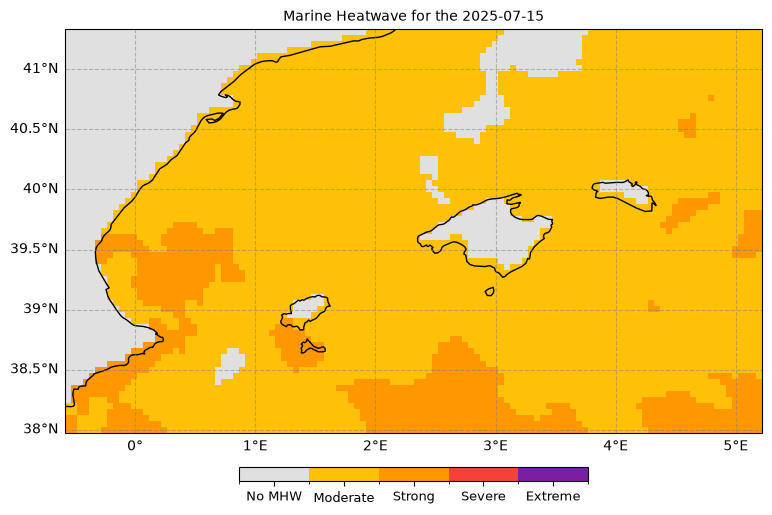

In [21]:
doi = "2025-07-15"
fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# (land overlay keeps coastlines clean)
ax.add_feature(cfeature.LAND, facecolor="#e6e6e6", edgecolor="none")
ax.add_feature(cfeature.COASTLINE, linewidth=1.0, edgecolor="black")
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5, edgecolor="gray")

# select our data
plot_obj = categories_2025.sel(time="2025-07-15").plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
    shading="nearest"
)
gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False
ax.set_title((f'Marine Heatwave for the {doi}'), fontsize=10 , y=1)
cax = ax.inset_axes([0.25, -0.12, 0.50, 0.035])
cbar = fig.colorbar(plot_obj, cax=cax, orientation="horizontal", ticks=[0, 1, 2, 3, 4])
cbar.ax.tick_params(labelsize=9)
cbar.ax.set_xticklabels(['No MHW', 'Moderate', 'Strong', 'Severe', 'Extreme'])
plt.show()

#### Monthly Aggregation

While daily snapshots reveal spatial details, aggregated monthly metrics help us track heat stress duration across important marine habitats.<br>
A key indicator on the [My Ocean portal](https://myoceanhealth.marine.copernicus.eu/en) is the monthly count of days experiencing Strong or higher MHWs (Category $\ge 2$).<br>
We resample our daily 2025 dataset by month (July, August, and September) and sum the instances where MHW categories meet or exceed **Category 2**.

In [22]:
monthly_condition = (categories_2025 >= 2)
monthly_strong_days = monthly_condition.resample(time="1MS").sum(dim="time")
monthly_strong_days

<xarray.DataArray 'analysed_sst' (time: 3, latitude: 67, longitude: 116)> Size: 187kB
array([[[16, 15, 14, ..., 18, 17, 16],
        [16, 16, 14, ..., 17, 17, 18],
        [17, 17, 14, ..., 17, 17, 17],
        ...,
        [ 0,  0,  0, ...,  4,  4,  4],
        [ 0,  0,  0, ...,  4,  4,  4],
        [ 0,  0,  0, ...,  5,  4,  4]],

       [[ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        ...,
        [ 0,  0,  0, ...,  4,  3,  2],
        [ 0,  0,  0, ...,  2,  3,  3],
        [ 0,  0,  0, ...,  1,  1,  2]],

       [[ 0,  0,  0, ...,  3,  1,  2],
        [ 0,  0,  0, ...,  3,  1,  1],
        [ 0,  0,  0, ...,  2,  1,  2],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]]], shape=(3, 67, 116))
Coordinates:
  * time       (time) datetime64[ns] 24B 2025-07-01 2025-08-01 2025-09-01
  * latitude   (latitude) float32 268B 38.0 38.05 38.1 ... 41.21 41.26 41.31
  * longitude  (longitude) float32 464B -0.5589 -0.5088 -0.4588 ... 5.146 5.196
    quantile   float64 8B 0.9

To visualise this monthly accumulation, we build a custom continuous colour ramp transitioning from white to deep cherry red:

In [23]:
cherry_colors = ["#ffffff", "#d36165", "#95000ae5"]  
cherry_cmap = mcolors.LinearSegmentedColormap.from_list("WhiteToCherry", cherry_colors)

Finally, we render a comparison map illustrating monthly heatwave exposure across the Balearic Sea:

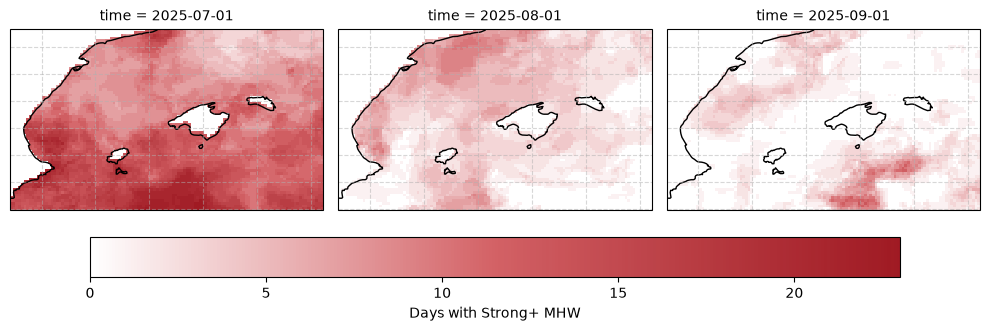

In [24]:
# side-by-side comparison map
g = monthly_strong_days.plot.pcolormesh(
    col="time",
    transform=ccrs.PlateCarree(),
    subplot_kws={"projection": ccrs.PlateCarree()},
    cmap = cherry_cmap ,
    cbar_kwargs={"label": "Days with Strong+ MHW", "orientation": "horizontal", "pad": 0.1}
)

# land and coastlines to each subplot
for ax in g.axs.flat:
    ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.gridlines(draw_labels=False, linestyle="--", alpha=0.5)

plt.show()

<hr>

<a id="example4"></a>

## 3️⃣ : Now it is your turn 💪

Now that we have mastered the SST pipeline in the Balearic Sea, the same analytical framework can be applied to other critical marine ecosystems across Spain.

To master your skills we propose Exploring the **Galician Coast**. Galicia’s sheltered coastal inlets (*rías*) produce the majority of Spain’s cultivated mussels (*Mytilus galloprovincialis*) and support world-renowned shellfish beds. High sea surface temperatures disrupt toxic algal bloom dynamics (red tides), leading to prolonged harvesting closures and economic losses for local mariculture.

- Define Your Bounding Box: Visit [bboxfinder.com](https://bboxfinder.com/) to select your area of interest.
- Select the Atlantic SST Dataset: Query the Atlantic high-resolution reprocessed dataset (`SST_ATL_SST_L4_REP_OBSERVATIONS_010_026`) from the Copernicus Marine Catalogue.
- Recalculate Your Baseline: Compute the 30-year reference baseline ($T_{\text{mean}}$, $T_{90}$, and $\Delta T$) for your new Atlantic bounding box.
- Extract 2025 Summer Data: Pull data for July, August, and September 2025.
- Visualise Daily & Monthly MHW Snapshots:
    * Plot the MHW category map for the middle day of each month (July 15, August 15, and September 15).
    *  Generate a 3-panel map showing the monthly count of Strong or Above ($\ge\text{Cat II}$) MHW days to evaluate thermal stress!

<hr>

<a id="example5"></a>

## 4️⃣ : Conclusion

In this tutorial, we bridged the gap between web-based visualisation tools and high-resolution, reproducible oceanographic analysis. By moving beyond default platform viewports, we demonstrated how Python, the `copernicusmarine` **API**, and `xarray` allow experts to programmatically explore Copernicus Marine Data Store products for localised impact studies.
Whether evaluating SST in the Mediterranean or tracking disruptions along the Galician Atlantic coast, this open-source pipeline provides the foundational toolkit for monitoring ocean warming impacts across Spain's marine ecosystems.

#### Resources

| Category | Resource / Paper | Description & Link |
| :--- | :--- | :--- |
| **Copernicus Marine** | **Copernicus Marine Data Store** | Web catalog interface to explore products, datasets, and metadata. [Access Portal](https://data.marine.copernicus.eu/products) |
| **Copernicus Marine Toolbox** | Official documentation for the `copernicusmarine` Python API and CLI.| [Read Docs](https://help.marine.copernicus.eu/en/collections/9110377-copernicus-marine-toolbox) |
| **My Ocean Health Portal** | Interactive global portal visualising ocean indicators and MHW categories.| [Open Portal](https://myoceanhealth.marine.copernicus.eu/en) |
| **MHW Methodology** | **Hobday et al. (2016)** | *A hierarchical approach to defining marine heatwaves* (Journal of Marine Systems) [Read Paper](https://passage.phys.ocean.dal.ca/~olivere/docs/Hobdayetal_2016_PO_HierarchMHWDefn.pdf)|
| **Python Toolkits** | **`xarray` Documentation** | Core library for multi-dimensional arrays, lazy loading, and spatial resampling.[Read Docs](https://docs.xarray.dev/en/stable/) |
| **`Cartopy` Documentation** | Geographic projection and mapping toolkit for Matplotlib. | [Read Docs](https://scitools.org.uk/cartopy/docs/latest/) |

`Happy EO coding :)!` 🛰️

<hr>

&copy; 2026 thriveGEO GmbH
